## Data Warehouse — Producto 1er Parcial
Extracción del Conocimiento de Base de Datos

## Celda 2: Importaciones y Configuración de Conexión

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from faker import Faker
import random
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURACIÓN DE CONEXIÓN A POSTGRESQL
# Ajusta estos parámetros según tu instalación de PostgreSQL
# ============================================================
DB_USER     = 'postgres'       # Usuario de PostgreSQL
DB_PASSWORD = '1234'           # Contraseña 
DB_HOST     = 'localhost'      # Host (generalmente localhost)
DB_PORT     = '5432'           # Puerto por defecto de PostgreSQL
DB_NAME     = 'dw_ventas'      # Nombre de la base de datos del DW

# Cadena de conexión SQLAlchemy
CONNECTION_STRING = f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'

print('✅ Configuración lista')
print(f'   Base de datos: {DB_NAME}')
print(f'   Host: {DB_HOST}:{DB_PORT}')

✅ Configuración lista
   Base de datos: dw_ventas
   Host: localhost:5432


 ## Celda 3: Creación de la Base de Datos del Data Warehouse

In [2]:
# Crear engine de conexión
engine = create_engine(CONNECTION_STRING)

# ============================================================
# CREAR TABLAS DE DIMENSIÓN Y HECHOS
# Esquema: ESTRELLA (Star Schema)
# ============================================================

DDL_SCRIPT = """
-- ================================================
-- TABLAS DE DIMENSIÓN
-- ================================================

-- Dimensión Tiempo
CREATE TABLE IF NOT EXISTS dim_tiempo (
    id_tiempo     SERIAL PRIMARY KEY,
    fecha         DATE NOT NULL UNIQUE,
    dia           INTEGER,
    mes           INTEGER,
    nombre_mes    VARCHAR(20),
    trimestre     INTEGER,
    anio          INTEGER,
    dia_semana    VARCHAR(15),
    es_fin_semana BOOLEAN
);

-- Dimensión Cliente
CREATE TABLE IF NOT EXISTS dim_cliente (
    id_cliente  SERIAL PRIMARY KEY,
    nombre      VARCHAR(100) NOT NULL,
    email       VARCHAR(100),
    ciudad      VARCHAR(60),
    estado      VARCHAR(40),
    segmento    VARCHAR(30)   -- 'Minorista', 'Mayorista', 'Corporativo'
);

-- Dimensión Producto
CREATE TABLE IF NOT EXISTS dim_producto (
    id_producto  SERIAL PRIMARY KEY,
    nombre       VARCHAR(100) NOT NULL,
    categoria    VARCHAR(50),
    subcategoria VARCHAR(50),
    precio_base  NUMERIC(10,2),
    proveedor    VARCHAR(80)
);

-- Dimensión Región
CREATE TABLE IF NOT EXISTS dim_region (
    id_region  SERIAL PRIMARY KEY,
    ciudad     VARCHAR(60),
    estado     VARCHAR(40),
    region     VARCHAR(30),   -- 'Norte', 'Centro', 'Sur', 'Este', 'Oeste'
    pais       VARCHAR(30) DEFAULT 'México'
);

-- Dimensión Vendedor
CREATE TABLE IF NOT EXISTS dim_vendedor (
    id_vendedor  SERIAL PRIMARY KEY,
    nombre       VARCHAR(100) NOT NULL,
    departamento VARCHAR(50),
    zona         VARCHAR(40)
);

-- ================================================
-- TABLA DE HECHOS (FACT TABLE)
-- ================================================

CREATE TABLE IF NOT EXISTS fact_ventas (
    id_venta     SERIAL PRIMARY KEY,
    id_tiempo    INTEGER REFERENCES dim_tiempo(id_tiempo),
    id_cliente   INTEGER REFERENCES dim_cliente(id_cliente),
    id_producto  INTEGER REFERENCES dim_producto(id_producto),
    id_region    INTEGER REFERENCES dim_region(id_region),
    id_vendedor  INTEGER REFERENCES dim_vendedor(id_vendedor),
    cantidad     INTEGER NOT NULL,
    precio_unitario NUMERIC(10,2) NOT NULL,
    descuento    NUMERIC(5,2) DEFAULT 0,
    monto_total  NUMERIC(12,2) NOT NULL,
    canal_venta  VARCHAR(30)  -- 'Online', 'Tienda', 'Distribuidor'
);
"""

with engine.connect() as conn:
    conn.execute(text(DDL_SCRIPT))
    conn.commit()

print('✅ Tablas creadas exitosamente en PostgreSQL')
print('   - dim_tiempo')
print('   - dim_cliente')
print('   - dim_producto')
print('   - dim_region')
print('   - dim_vendedor')
print('   - fact_ventas')

✅ Tablas creadas exitosamente en PostgreSQL
   - dim_tiempo
   - dim_cliente
   - dim_producto
   - dim_region
   - dim_vendedor
   - fact_ventas


## Celda 4: Generación de Datos Simulados

In [3]:
fake = Faker('es_MX')
random.seed(42)
np.random.seed(42)

# ============================================================
# DIMENSIÓN TIEMPO: 2 años de fechas (2023-2024)
# ============================================================
meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
         'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']
dias_semana = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

fechas = pd.date_range('2023-01-01', '2024-12-31', freq='D')
df_tiempo = pd.DataFrame({
    'fecha':         fechas,
    'dia':           fechas.day,
    'mes':           fechas.month,
    'nombre_mes':    [meses[m-1] for m in fechas.month],
    'trimestre':     fechas.quarter,
    'anio':          fechas.year,
    'dia_semana':    [dias_semana[d] for d in fechas.dayofweek],
    'es_fin_semana': fechas.dayofweek >= 5
})
print(f'✅ dim_tiempo: {len(df_tiempo)} filas generadas')
df_tiempo.head(3)

✅ dim_tiempo: 731 filas generadas


,fecha,dia,mes,nombre_mes,trimestre,anio,dia_semana,es_fin_semana
0,2023-01-01,1,1,Enero,1,2023,Domingo,True
1,2023-01-02,2,1,Enero,1,2023,Lunes,False
2,2023-01-03,3,1,Enero,1,2023,Martes,False


In [4]:
# ============================================================
# DIMENSIÓN CLIENTE: 200 clientes
# ============================================================
ciudades_mx = ['Ciudad de México','Guadalajara','Monterrey','Puebla','Querétaro',
               'Mérida','Tijuana','Cancún','León','Orizaba']
estados_mx  = ['CDMX','Jalisco','Nuevo León','Puebla','Querétaro',
               'Yucatán','Baja California','Quintana Roo','Guanajuato','Veracruz']
ciudades_estados = list(zip(ciudades_mx, estados_mx))
segmentos = ['Minorista','Mayorista','Corporativo']

clientes = []
for _ in range(200):
    ciudad, estado = random.choice(ciudades_estados)
    clientes.append({
        'nombre':   fake.name(),
        'email':    fake.email(),
        'ciudad':   ciudad,
        'estado':   estado,
        'segmento': random.choices(segmentos, weights=[50,30,20])[0]
    })
df_cliente = pd.DataFrame(clientes)
print(f'✅ dim_cliente: {len(df_cliente)} filas generadas')
df_cliente.head(3)

✅ dim_cliente: 200 filas generadas


,nombre,email,ciudad,estado,segmento
0,María Teresa Norma Romo,tellezmaria-luisa@example.com,Guadalajara,Jalisco,Minorista
1,Sonia Camila Prieto,elias19@example.com,Querétaro,Querétaro,Minorista
2,Itzel Vera,carlota32@example.com,Monterrey,Nuevo León,Mayorista


In [5]:
# ============================================================
# DIMENSIÓN PRODUCTO: 50 productos en 5 categorías
# ============================================================
catalogo = {
    'Electrónica': {
        'Smartphones': ['iPhone 14','Samsung S23','Xiaomi 13','Motorola G84','Huawei P50'],
        'Laptops':     ['MacBook Air','Dell XPS','HP Pavilion','Lenovo ThinkPad','Asus VivoBook'],
    },
    'Ropa': {
        'Hombre':  ['Camisa Oxford','Pantalón Chino','Chamarra Denim','Sudadera Fleece','Polo Slim'],
        'Mujer':   ['Blusa Seda','Vestido Casual','Jeans Skinny','Abrigo Lana','Top Crop'],
    },
    'Alimentos': {
        'Bebidas': ['Agua 1L','Refresco 600ml','Jugo Natural','Café Molido','Té Verde'],
        'Snacks':  ['Papas Fritas','Galletas Choco','Nueces Mix','Barra Proteína','Fruta Deshidratada'],
    },
    'Hogar': {
        'Muebles':  ['Silla Gaming','Mesa Escritorio','Estante Madera','Sofá 3 Plazas','Cama Queen'],
        'Cocina':   ['Licuadora 700W','Cafetera French','Sartén Teflón','Juego Cuchillos','Olla Express'],
    },
    'Deportes': {
        'Fitness':  ['Mancuernas 10kg','Colchoneta Yoga','Banda Resistencia','Cuerda Saltar','Guantes Box'],
        'Outdoor':  ['Bicicleta MTB','Casco Ciclismo','Mochila Trail','Zapatos Running','Tent 2 Personas'],
    }
}
precios = {'Electrónica':(800,25000),'Ropa':(150,2500),'Alimentos':(15,350),'Hogar':(200,18000),'Deportes':(100,12000)}
proveedores = ['TechSupply SA','DistribuidoraMX','ImportExport MX','Mayorista Central','LogiPro México']

productos = []
for cat, subcats in catalogo.items():
    for subcat, items in subcats.items():
        pmin, pmax = precios[cat]
        for item in items:
            productos.append({
                'nombre':       item,
                'categoria':    cat,
                'subcategoria': subcat,
                'precio_base':  round(random.uniform(pmin, pmax), 2),
                'proveedor':    random.choice(proveedores)
            })
df_producto = pd.DataFrame(productos)
print(f'✅ dim_producto: {len(df_producto)} filas generadas')
df_producto.head(3)

✅ dim_producto: 50 filas generadas


,nombre,categoria,subcategoria,precio_base,proveedor
0,iPhone 14,Electrónica,Smartphones,24618.51,TechSupply SA
1,Samsung S23,Electrónica,Smartphones,10121.73,LogiPro México
2,Xiaomi 13,Electrónica,Smartphones,5399.91,TechSupply SA


In [6]:
# ============================================================
# DIMENSIÓN REGIÓN: 10 ciudades de México
# ============================================================
regiones_data = [
    ('Ciudad de México','CDMX','Centro'),
    ('Guadalajara','Jalisco','Occidente'),
    ('Monterrey','Nuevo León','Norte'),
    ('Puebla','Puebla','Centro'),
    ('Querétaro','Querétaro','Centro'),
    ('Mérida','Yucatán','Sur'),
    ('Tijuana','Baja California','Norte'),
    ('Cancún','Quintana Roo','Sur'),
    ('León','Guanajuato','Centro'),
    ('Orizaba','Veracruz','Sur'),
]
df_region = pd.DataFrame(regiones_data, columns=['ciudad','estado','region'])
df_region['pais'] = 'México'
print(f'✅ dim_region: {len(df_region)} filas generadas')
df_region

✅ dim_region: 10 filas generadas


,ciudad,estado,region,pais
0,Ciudad de México,CDMX,Centro,México
1,Guadalajara,Jalisco,Occidente,México
2,Monterrey,Nuevo León,Norte,México
3,Puebla,Puebla,Centro,México
4,Querétaro,Querétaro,Centro,México
5,Mérida,Yucatán,Sur,México
6,Tijuana,Baja California,Norte,México
7,Cancún,Quintana Roo,Sur,México
8,León,Guanajuato,Centro,México
9,Orizaba,Veracruz,Sur,México


In [7]:
# ============================================================
# DIMENSIÓN VENDEDOR: 15 vendedores
# ============================================================
departamentos = ['Ventas Norte','Ventas Centro','Ventas Sur','Canal Online','Distribución']
zonas = ['Norte','Centro','Sur','Nacional','Online']

vendedores = []
for i in range(15):
    dpto = departamentos[i % len(departamentos)]
    vendedores.append({
        'nombre':       fake.name(),
        'departamento': dpto,
        'zona':         zonas[i % len(zonas)]
    })
df_vendedor = pd.DataFrame(vendedores)
print(f'✅ dim_vendedor: {len(df_vendedor)} filas generadas')
df_vendedor.head(3)

✅ dim_vendedor: 15 filas generadas


,nombre,departamento,zona
0,Eloy Juan Rodríquez,Ventas Norte,Norte
1,Elvia Soledad Arteaga,Ventas Centro,Centro
2,Sergio Emilio Ballesteros Vargas,Ventas Sur,Sur


## Celda 5: Transformación y Carga al Data Warehouse (ETL — Transform & Load)¶

In [8]:
# ============================================================
# CARGA DE DIMENSIONES AL POSTGRESQL
# ============================================================

def cargar_dimension(df, tabla, engine):
    """Carga un DataFrame a una tabla de dimensión en PostgreSQL."""
    # Limpiar valores nulos y normalizar strings
    df_clean = df.copy()
    for col in df_clean.select_dtypes(include='object').columns:
        df_clean[col] = df_clean[col].str.strip()
    
    # Eliminar datos existentes para recarga limpia
    with engine.connect() as conn:
        conn.execute(text(f'TRUNCATE TABLE {tabla} RESTART IDENTITY CASCADE'))
        conn.commit()
    
    # Cargar al DW
    filas = df_clean.to_sql(tabla, engine, if_exists='append', index=False)
    print(f'   ✅ {tabla}: {len(df_clean)} registros cargados')
    return df_clean

print('🔄 Iniciando carga de dimensiones...')
cargar_dimension(df_tiempo,   'dim_tiempo',   engine)
cargar_dimension(df_cliente,  'dim_cliente',  engine)
cargar_dimension(df_producto, 'dim_producto', engine)
cargar_dimension(df_region,   'dim_region',   engine)
cargar_dimension(df_vendedor, 'dim_vendedor', engine)
print('\n✅ Todas las dimensiones cargadas exitosamente')

🔄 Iniciando carga de dimensiones...
   ✅ dim_tiempo: 731 registros cargados
   ✅ dim_cliente: 200 registros cargados
   ✅ dim_producto: 50 registros cargados
   ✅ dim_region: 10 registros cargados
   ✅ dim_vendedor: 15 registros cargados

✅ Todas las dimensiones cargadas exitosamente


In [9]:
# ============================================================
# GENERAR Y CARGAR TABLA DE HECHOS: 5,000 ventas
# ============================================================

# Obtener IDs desde el DW (post-carga)
with engine.connect() as conn:
    ids_tiempo   = pd.read_sql('SELECT id_tiempo FROM dim_tiempo', conn)['id_tiempo'].tolist()
    ids_cliente  = pd.read_sql('SELECT id_cliente FROM dim_cliente', conn)['id_cliente'].tolist()
    precios_prod = pd.read_sql('SELECT id_producto, precio_base FROM dim_producto', conn)
    ids_region   = pd.read_sql('SELECT id_region FROM dim_region', conn)['id_region'].tolist()
    ids_vendedor = pd.read_sql('SELECT id_vendedor FROM dim_vendedor', conn)['id_vendedor'].tolist()

canales = ['Online','Tienda','Distribuidor']
ventas = []

for _ in range(5000):
    prod = precios_prod.sample(1).iloc[0]
    cantidad   = random.randint(1, 20)
    descuento  = round(random.choices([0, 5, 10, 15, 20], weights=[40,20,20,10,10])[0], 2)
    precio     = round(prod['precio_base'] * (1 - descuento/100), 2)
    monto      = round(precio * cantidad, 2)
    
    ventas.append({
        'id_tiempo':       random.choice(ids_tiempo),
        'id_cliente':      random.choice(ids_cliente),
        'id_producto':     int(prod['id_producto']),
        'id_region':       random.choice(ids_region),
        'id_vendedor':     random.choice(ids_vendedor),
        'cantidad':        cantidad,
        'precio_unitario': precio,
        'descuento':       descuento,
        'monto_total':     monto,
        'canal_venta':     random.choices(canales, weights=[40,45,15])[0]
    })

df_ventas = pd.DataFrame(ventas)

# Truncar y cargar
with engine.connect() as conn:
    conn.execute(text('TRUNCATE TABLE fact_ventas RESTART IDENTITY'))
    conn.commit()

df_ventas.to_sql('fact_ventas', engine, if_exists='append', index=False)
print(f'✅ fact_ventas: {len(df_ventas)} registros cargados')
df_ventas.head()

✅ fact_ventas: 5000 registros cargados


,id_tiempo,id_cliente,id_producto,id_region,id_vendedor,cantidad,precio_unitario,descuento,monto_total,canal_venta
0,282,113,14,2,12,16,1024.24,10,16387.84,Online
1,553,21,30,3,3,9,344.62,0,3101.58,Online
2,66,107,2,7,6,5,9109.56,10,45547.80,Tienda
3,430,100,50,10,12,14,9213.18,0,128984.52,Online
4,7,91,36,5,13,19,16089.34,0,305697.46,Online


##  Celda 6: Exportar Datos a CSV (evidencia de carga)

In [10]:
import os
os.makedirs('datos_csv', exist_ok=True)

df_tiempo.to_csv('datos_csv/dim_tiempo.csv', index=False)
df_cliente.to_csv('datos_csv/dim_cliente.csv', index=False)
df_producto.to_csv('datos_csv/dim_producto.csv', index=False)
df_region.to_csv('datos_csv/dim_region.csv', index=False)
df_vendedor.to_csv('datos_csv/dim_vendedor.csv', index=False)
df_ventas.to_csv('datos_csv/fact_ventas.csv', index=False)

print('✅ Archivos CSV exportados en carpeta datos_csv/')
for f in os.listdir('datos_csv'):
    size = os.path.getsize(f'datos_csv/{f}')
    print(f'   {f}: {size:,} bytes')

✅ Archivos CSV exportados en carpeta datos_csv/
   dim_cliente.csv: 15,587 bytes
   dim_producto.csv: 2,796 bytes
   dim_region.csv: 376 bytes
   dim_tiempo.csv: 32,908 bytes
   dim_vendedor.csv: 712 bytes
   fact_ventas.csv: 224,380 bytes


## Celda 7: Consultas SQL Analíticas sobre el Data Warehouse

In [11]:
# ============================================================
# CONSULTA 1: Ventas totales por mes y año
# ============================================================
query_1 = """
SELECT 
    t.anio,
    t.nombre_mes,
    t.mes,
    COUNT(fv.id_venta)       AS num_ventas,
    SUM(fv.cantidad)         AS unidades_vendidas,
    ROUND(SUM(fv.monto_total)::numeric, 2) AS ingresos_totales
FROM fact_ventas fv
JOIN dim_tiempo t ON fv.id_tiempo = t.id_tiempo
GROUP BY t.anio, t.mes, t.nombre_mes
ORDER BY t.anio, t.mes;
"""
with engine.connect() as conn:
    df_mensual = pd.read_sql(query_1, conn)

print('📅 Ventas por Mes y Año:')
df_mensual

📅 Ventas por Mes y Año:


,anio,nombre_mes,mes,num_ventas,unidades_vendidas,ingresos_totales
0,2023,Enero,1,199,2212,13564358.87
1,2023,Febrero,2,186,2044,10825173.34
2,2023,Marzo,3,232,2642,16486766.98
3,2023,Abril,4,231,2378,15734537.13
4,2023,Mayo,5,217,2370,16482056.64
5,2023,Junio,6,214,2335,13425619.06
6,2023,Julio,7,198,2113,12851942.45
7,2023,Agosto,8,196,2182,12685016.83
8,2023,Septiembre,9,210,2188,12071200.56
9,2023,Octubre,10,217,2300,15309551.84


In [12]:
# ============================================================
# CONSULTA 2: Top 10 productos más vendidos
# ============================================================
query_2 = """
SELECT 
    p.nombre                               AS producto,
    p.categoria,
    SUM(fv.cantidad)                       AS unidades,
    ROUND(SUM(fv.monto_total)::numeric, 2) AS ingresos
FROM fact_ventas fv
JOIN dim_producto p ON fv.id_producto = p.id_producto
GROUP BY p.nombre, p.categoria
ORDER BY ingresos DESC
LIMIT 10;
"""
with engine.connect() as conn:
    df_top_productos = pd.read_sql(query_2, conn)

print('🏆 Top 10 Productos por Ingresos:')
df_top_productos

🏆 Top 10 Productos por Ingresos:


,producto,categoria,unidades,ingresos
0,iPhone 14,Electrónica,1067,24464644.23
1,HP Pavilion,Electrónica,985,21691834.86
2,Asus VivoBook,Electrónica,1134,19355766.22
3,Motorola G84,Electrónica,1062,17753326.14
4,Lenovo ThinkPad,Electrónica,1160,17271478.91
5,MacBook Air,Electrónica,1040,16922801.88
6,Silla Gaming,Hogar,1167,16599630.78
7,Cafetera French,Hogar,1210,15743288.96
8,Licuadora 700W,Hogar,941,14107133.81
9,Huawei P50,Electrónica,896,11093736.57


In [13]:
# ============================================================
# CONSULTA 3: Ingresos por región
# ============================================================
query_3 = """
SELECT 
    r.ciudad,
    r.region,
    COUNT(fv.id_venta)                        AS num_ventas,
    ROUND(SUM(fv.monto_total)::numeric, 2)    AS ingresos_totales,
    ROUND(AVG(fv.monto_total)::numeric, 2)    AS ticket_promedio
FROM fact_ventas fv
JOIN dim_region r ON fv.id_region = r.id_region
GROUP BY r.ciudad, r.region
ORDER BY ingresos_totales DESC;
"""
with engine.connect() as conn:
    df_region_ventas = pd.read_sql(query_3, conn)

print('🗺️ Ventas por Región:')
df_region_ventas

🗺️ Ventas por Región:


,ciudad,region,num_ventas,ingresos_totales,ticket_promedio
0,Orizaba,Sur,527,35860887.23,68047.22
1,Tijuana,Norte,536,34985502.39,65271.46
2,Cancún,Sur,513,34226908.38,66719.12
3,Monterrey,Norte,498,34103816.32,68481.56
4,Guadalajara,Occidente,504,31989730.84,63471.69
5,Querétaro,Centro,472,31165494.51,66028.59
6,Ciudad de México,Centro,492,31013688.92,63035.95
7,Mérida,Sur,481,30748700.73,63926.61
8,León,Centro,508,30499058.40,60037.52
9,Puebla,Centro,469,28795346.02,61397.33


In [14]:
# ============================================================
# CONSULTA 4: Ventas por categoría de producto
# ============================================================
query_4 = """
SELECT 
    p.categoria,
    COUNT(fv.id_venta)                        AS num_ventas,
    SUM(fv.cantidad)                          AS unidades,
    ROUND(SUM(fv.monto_total)::numeric, 2)    AS ingresos
FROM fact_ventas fv
JOIN dim_producto p ON fv.id_producto = p.id_producto
GROUP BY p.categoria
ORDER BY ingresos DESC;
"""
with engine.connect() as conn:
    df_categorias = pd.read_sql(query_4, conn)

print('📦 Ventas por Categoría:')# ============================================================
# CONSULTA 5: Rendimiento por canal de venta
# ============================================================
query_5 = """
SELECT 
    canal_venta,
    COUNT(*)                                  AS num_transacciones,
    ROUND(SUM(monto_total)::numeric, 2)       AS ingresos_totales,
    ROUND(AVG(monto_total)::numeric, 2)       AS ticket_promedio,
    ROUND(AVG(descuento)::numeric, 2)         AS descuento_promedio
FROM fact_ventas
GROUP BY canal_venta
ORDER BY ingresos_totales DESC;
"""
with engine.connect() as conn:
    df_canal = pd.read_sql(query_5, conn)
# ============================================================
# CONSULTA 6: Top 5 vendedores
# ============================================================
query_6 = """
SELECT 
    v.nombre                                  AS vendedor,
    v.zona,
    COUNT(fv.id_venta)                        AS ventas_realizadas,
    ROUND(SUM(fv.monto_total)::numeric, 2)    AS ingresos_generados
FROM fact_ventas fv
JOIN dim_vendedor v ON fv.id_vendedor = v.id_vendedor
GROUP BY v.nombre, v.zona
ORDER BY ingresos_generados DESC
LIMIT 5;
"""
with engine.connect() as conn:
    df_top_vendedores = pd.read_sql(query_6, conn)

print('👥 Top 5 Vendedores:')
df_top_vendedores
print('🛒 Ventas por Canal:')
df_canal
df_categorias

📦 Ventas por Categoría:
👥 Top 5 Vendedores:
🛒 Ventas por Canal:


,categoria,num_ventas,unidades,ingresos
0,Electrónica,964,10223,1.511162e+08
1,Hogar,1020,10704,8.711202e+07
2,Deportes,981,10401,7.003846e+07
3,Ropa,1002,10704,1.296825e+07
4,Alimentos,1033,11310,2.154223e+06


## Celda 8: Visualizaciones con Matplotlib

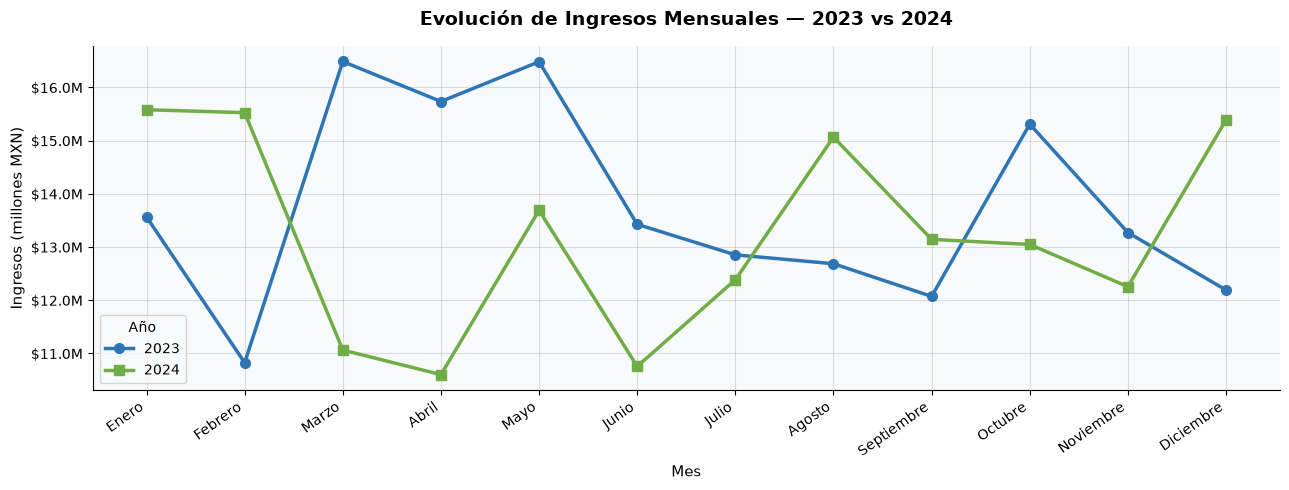

💾 Guardada: graficas/01_ingresos_mensuales.png


In [15]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Colores
AZUL    = '#2E75B6'
VERDE   = '#70AD47'
NARANJA = '#ED7D31'
MORADO  = '#7030A0'
COLORES = [AZUL, VERDE, NARANJA, '#FFC000', MORADO, '#4BACC6', '#C00000', '#92D050', '#00B0F0', '#FF7F50']

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False
})

os.makedirs('graficas', exist_ok=True)

# ============================================================
# GRÁFICA 1: Ingresos mensuales 2023 vs 2024 (líneas)
# ============================================================
fig, ax = plt.subplots(figsize=(13, 5))

for anio, color, marker in [(2023, AZUL, 'o'), (2024, VERDE, 's')]:
    datos = df_mensual[df_mensual['anio'] == anio].sort_values('mes')
    ax.plot(datos['nombre_mes'], datos['ingresos_totales']/1e6,
            marker=marker, color=color, linewidth=2.5, markersize=7, label=str(anio))

ax.set_title('Evolución de Ingresos Mensuales — 2023 vs 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mes')
ax.set_ylabel('Ingresos (millones MXN)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fM'))
ax.legend(title='Año', fontsize=10)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('graficas/01_ingresos_mensuales.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardada: graficas/01_ingresos_mensuales.png')

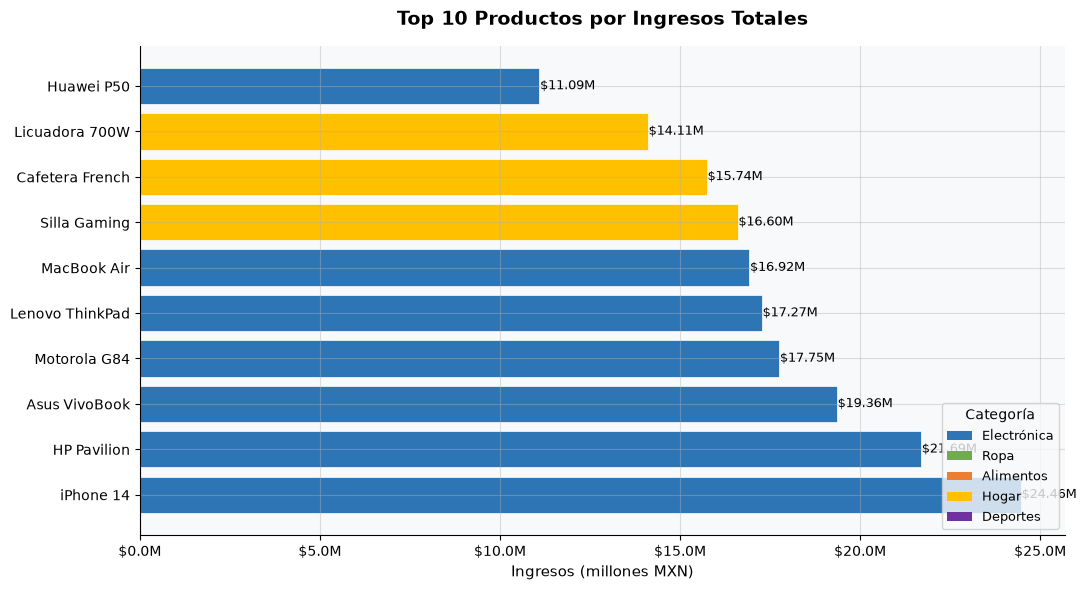

💾 Guardada: graficas/02_top_productos.png


In [16]:
# ============================================================
# GRÁFICA 2: Top 10 productos por ingresos (barras horizontales)
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6))

colores_cat = {'Electrónica': AZUL,'Ropa': VERDE,'Alimentos': NARANJA,'Hogar': '#FFC000','Deportes': MORADO}
bar_colors = [colores_cat.get(c, AZUL) for c in df_top_productos['categoria']]

bars = ax.barh(df_top_productos['producto'], df_top_productos['ingresos']/1e6,
               color=bar_colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, df_top_productos['ingresos']/1e6):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}M', va='center', fontsize=9)

ax.set_title('Top 10 Productos por Ingresos Totales', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ingresos (millones MXN)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fM'))

# Leyenda de categorías
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colores_cat.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, title='Categoría')

plt.tight_layout()
plt.savefig('graficas/02_top_productos.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardada: graficas/02_top_productos.png')

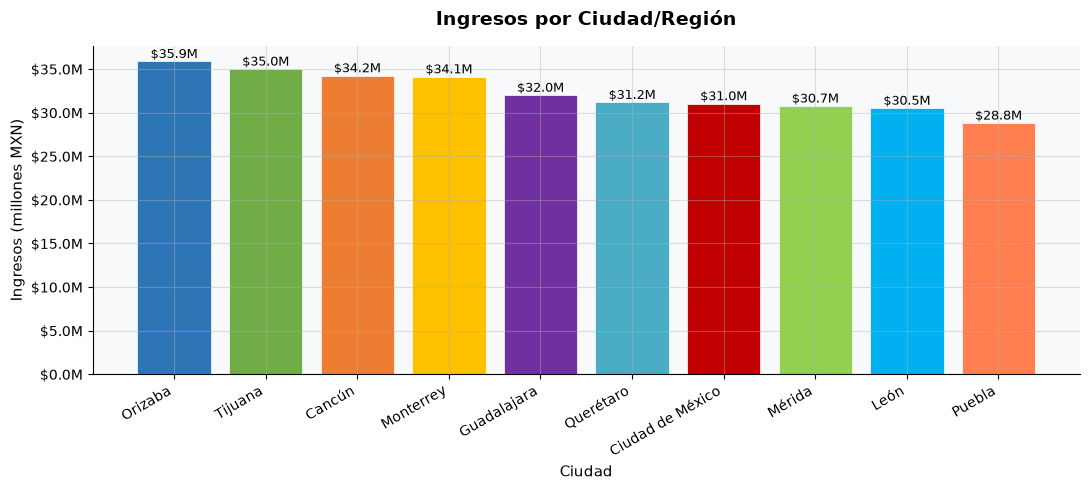

💾 Guardada: graficas/03_ventas_region.png


In [17]:
# ============================================================
# GRÁFICA 3: Ventas por región (barras verticales)
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5))

df_sorted = df_region_ventas.sort_values('ingresos_totales', ascending=False)
bars = ax.bar(df_sorted['ciudad'], df_sorted['ingresos_totales']/1e6,
              color=COLORES[:len(df_sorted)], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, df_sorted['ingresos_totales']/1e6):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'${val:.1f}M', ha='center', va='bottom', fontsize=9)

ax.set_title('Ingresos por Ciudad/Región', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ciudad')
ax.set_ylabel('Ingresos (millones MXN)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fM'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('graficas/03_ventas_region.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardada: graficas/03_ventas_region.png')

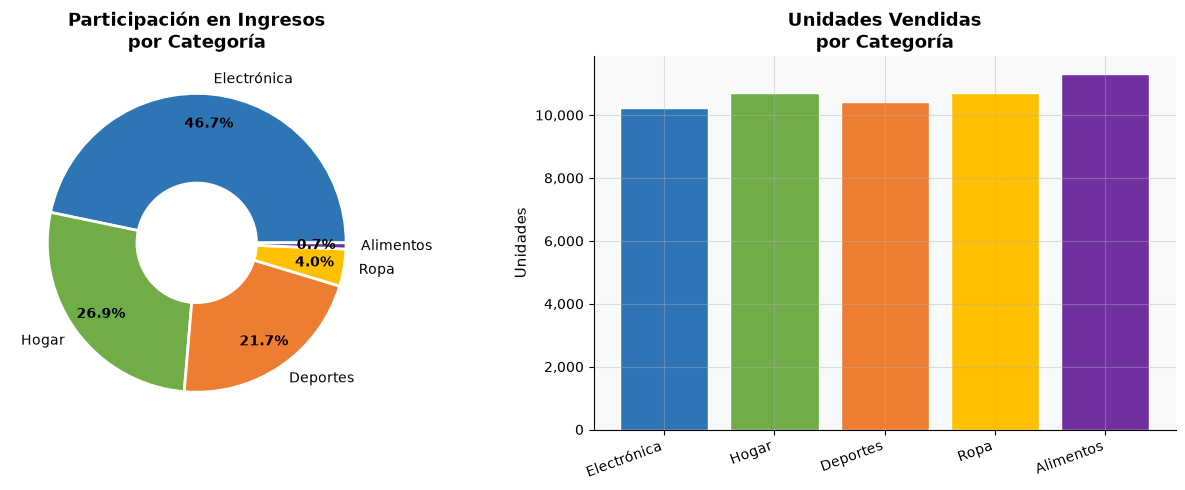

💾 Guardada: graficas/04_categorias.png


In [18]:
# ============================================================
# GRÁFICA 4: Participación por categoría (pastel)
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Donut chart por ingresos
wedges, texts, autotexts = ax1.pie(
    df_categorias['ingresos'],
    labels=df_categorias['categoria'],
    autopct='%1.1f%%',
    colors=COLORES[:len(df_categorias)],
    pctdistance=0.8,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax1.set_title('Participación en Ingresos\npor Categoría', fontsize=13, fontweight='bold')

# Barras por unidades vendidas
ax2.bar(df_categorias['categoria'], df_categorias['unidades'],
        color=COLORES[:len(df_categorias)], edgecolor='white')
ax2.set_title('Unidades Vendidas\npor Categoría', fontsize=13, fontweight='bold')
ax2.set_ylabel('Unidades')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.savefig('graficas/04_categorias.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardada: graficas/04_categorias.png')

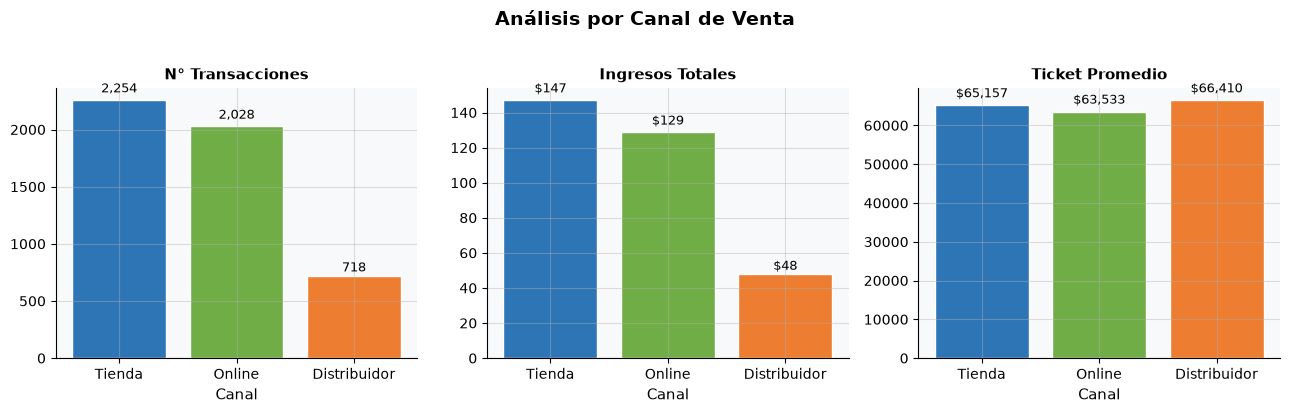

💾 Guardada: graficas/05_canales.png


In [19]:
# ============================================================
# GRÁFICA 5: Comparativa de canales de venta
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

metricas = [
    ('num_transacciones', 'N° Transacciones', '{}'),
    ('ingresos_totales',  'Ingresos Totales', '${:.0f}'),
    ('ticket_promedio',   'Ticket Promedio',  '${:.0f}')
]

for ax, (col, titulo, fmt) in zip(axes, metricas):
    vals = df_canal[col] / (1e6 if col == 'ingresos_totales' else 1)
    bars = ax.bar(df_canal['canal_venta'], vals,
                  color=[AZUL, VERDE, NARANJA], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{v:,.0f}' if col == 'num_transacciones' else f'${v:,.0f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Canal')

fig.suptitle('Análisis por Canal de Venta', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficas/05_canales.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardada: graficas/05_canales.png')

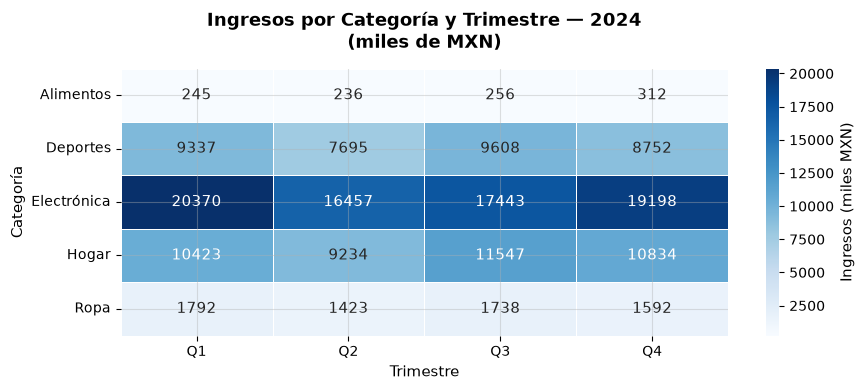

💾 Guardada: graficas/06_heatmap_trimestral.png


In [20]:
# ============================================================
# GRÁFICA 6: Heatmap de ventas por trimestre y categoría
# ============================================================
query_heat = """
SELECT 
    p.categoria,
    t.trimestre,
    ROUND(SUM(fv.monto_total)::numeric / 1000, 2) AS ingresos_miles
FROM fact_ventas fv
JOIN dim_producto p ON fv.id_producto = p.id_producto
JOIN dim_tiempo   t ON fv.id_tiempo   = t.id_tiempo
WHERE t.anio = 2024
GROUP BY p.categoria, t.trimestre
ORDER BY p.categoria, t.trimestre;
"""
with engine.connect() as conn:
    df_heat = pd.read_sql(query_heat, conn)

pivot = df_heat.pivot(index='categoria', columns='trimestre', values='ingresos_miles')
pivot.columns = ['Q1','Q2','Q3','Q4']

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11},
            cbar_kws={'label': 'Ingresos (miles MXN)'}, ax=ax)
ax.set_title('Ingresos por Categoría y Trimestre — 2024\n(miles de MXN)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Trimestre')
ax.set_ylabel('Categoría')
plt.tight_layout()
plt.savefig('graficas/06_heatmap_trimestral.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardada: graficas/06_heatmap_trimestral.png')

## Celda 9: Validación del Data Warehouse

In [21]:
# ============================================================
# VALIDACIÓN: Conteo de registros por tabla
# ============================================================
tablas = ['dim_tiempo','dim_cliente','dim_producto','dim_region','dim_vendedor','fact_ventas']

print('='*50)
print('   VALIDACIÓN DEL DATA WAREHOUSE')
print('='*50)
total_registros = 0
with engine.connect() as conn:
    for tabla in tablas:
        count = conn.execute(text(f'SELECT COUNT(*) FROM {tabla}')).scalar()
        tipo = 'FACT' if tabla.startswith('fact') else 'DIM '
        print(f'  [{tipo}] {tabla:<20}: {count:>6,} registros')
        total_registros += count
print('='*50)
print(f'  TOTAL REGISTROS EN DW    : {total_registros:>6,}')
print('='*50)

# Validar integridad referencial
query_integridad = """
SELECT 
    CASE WHEN COUNT(*) = 0 THEN 'OK - Sin huérfanos' ELSE 'ERROR - Hay registros huérfanos' END AS estado
FROM fact_ventas fv
LEFT JOIN dim_cliente  c ON fv.id_cliente  = c.id_cliente
LEFT JOIN dim_producto p ON fv.id_producto = p.id_producto
LEFT JOIN dim_tiempo   t ON fv.id_tiempo   = t.id_tiempo
WHERE c.id_cliente IS NULL OR p.id_producto IS NULL OR t.id_tiempo IS NULL;
"""
with engine.connect() as conn:
    resultado = conn.execute(text(query_integridad)).scalar()
print(f'\n  Integridad referencial: {resultado}')

   VALIDACIÓN DEL DATA WAREHOUSE
  [DIM ] dim_tiempo          :    731 registros
  [DIM ] dim_cliente         :    200 registros
  [DIM ] dim_producto        :     50 registros
  [DIM ] dim_region          :     10 registros
  [DIM ] dim_vendedor        :     15 registros
  [FACT] fact_ventas         :  5,000 registros
  TOTAL REGISTROS EN DW    :  6,006

  Integridad referencial: OK - Sin huérfanos
